# An intercept is an estimate, not evidence of skill

Ten constructed portfolios share factor and residual shocks but have no planted alpha. Estimate intercepts with serial-dependence-aware uncertainty, compare 60 versus 240 observations, and account for the declared family of ten tests. One realization illustrates interpretation; it does not validate test coverage.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Goal

A fitted intercept can be nonzero even when the data-generating model's
intercept is zero. This constructed ten-portfolio panel has six factor
exposures, correlated residual shocks, and AR(1) residual persistence.
Its population intercepts are all zero by construction; sample residual
means are not forced to zero before fitting.

We report six-lag Newey–West intervals with the study's finite-sample
correction and normal approximation. Multiplying intercepts and standard
errors by 12 expresses **annualized arithmetic alpha**, not compounded
returns. These are approximate intervals, especially in the short sample.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from research.models import hac_ols, holm_adjust

FIGURES = ROOT / "research" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(20260921)
n, burn, portfolios = 240, 120, 10
draws = rng.normal(size=(n + burn, 6))
factor_map = np.eye(6)
factor_map[1, 0], factor_map[2, 0] = 0.35, -0.25
factors = 0.025 * draws @ factor_map.T + 0.002
beta = rng.normal(0, 0.25, size=(6, portfolios))
beta[0] = np.linspace(0.6, 1.5, portfolios)
innovations = 0.009 * rng.normal(size=(n + burn, 1)) + 0.012 * rng.normal(size=(n + burn, portfolios))
residuals = np.zeros_like(innovations)
for t in range(1, n + burn):
    residuals[t] = 0.35 * residuals[t - 1] + innovations[t]
X = factors[burn:]
Y = (factors @ beta + residuals)[burn:]
names = [f"Portfolio {i + 1:02d}" for i in range(portfolios)]
display(pd.DataFrame({"Population alpha": np.zeros(portfolios),
                      "Planted market-factor slope": beta[0]}, index=names))

,Population alpha,Planted market-factor slope
Portfolio 01,0.0,0.6
Portfolio 02,0.0,0.7
Portfolio 03,0.0,0.8
Portfolio 04,0.0,0.9
Portfolio 05,0.0,1.0
Portfolio 06,0.0,1.1
Portfolio 07,0.0,1.2
Portfolio 08,0.0,1.3
Portfolio 09,0.0,1.4
Portfolio 10,0.0,1.5


### 1. Estimate a declared family of ten intercepts

Fit all six regressors with an intercept. Serial correlation motivates
HAC rather than an independent-observation standard error. The ten
full-sample intercepts form one testing family; the short-sample
diagnostic forms a separate, explicitly labeled family. Selecting
whichever sample appears most significant would require a wider family.

In [3]:
results = {}
fits = {}
for sample_size in [240, 60]:
    current = [hac_ols(X[-sample_size:], Y[-sample_size:, j], lags=6)
               for j in range(portfolios)]
    fits[sample_size] = current
    alpha = np.array([fit.coefficients[0] for fit in current])
    se = np.array([fit.standard_errors[0] for fit in current])
    p_values = np.array([fit.p_values[0] for fit in current])
    results[sample_size] = pd.DataFrame({
        "Alpha (%/year)": alpha * 1200,
        "Lower 95% (%/year)": (alpha - 1.96 * se) * 1200,
        "Upper 95% (%/year)": (alpha + 1.96 * se) * 1200,
        "Raw p-value": p_values,
        "Holm p-value, family of 10": holm_adjust(p_values),
    }, index=names)
display(results[240].round(4))

,Alpha (%/year),Lower 95% (%/year),Upper 95% (%/year),Raw p-value,"Holm p-value, family of 10"
Portfolio 01,0.0513,-2.9185,3.0211,0.9730,1.0000
Portfolio 02,0.5040,-2.7364,3.7444,0.7605,1.0000
Portfolio 03,1.4509,-2.0655,4.9672,0.4187,1.0000
Portfolio 04,-3.2466,-6.2720,-0.2212,0.0354,0.3544
Portfolio 05,1.9081,-1.8927,5.7089,0.3251,1.0000
Portfolio 06,-0.6799,-4.3637,3.0038,0.7175,1.0000
Portfolio 07,-1.3028,-3.8870,1.2815,0.3231,1.0000
Portfolio 08,-0.4206,-3.8705,3.0292,0.8111,1.0000
Portfolio 09,-2.1657,-5.0530,0.7216,0.1415,1.0000
Portfolio 10,-2.7828,-5.8927,0.3270,0.0794,0.7150


### 2. Keep the interval with the estimate

Each point is an estimated intercept; each line is its **pointwise**
95% normal-approximation HAC interval. They are not simultaneous
confidence intervals. Both panels use the same units, portfolio order,
and horizontal scale. Shorter histories can change estimates as well
as precision; the effect is measured here rather than guaranteed.

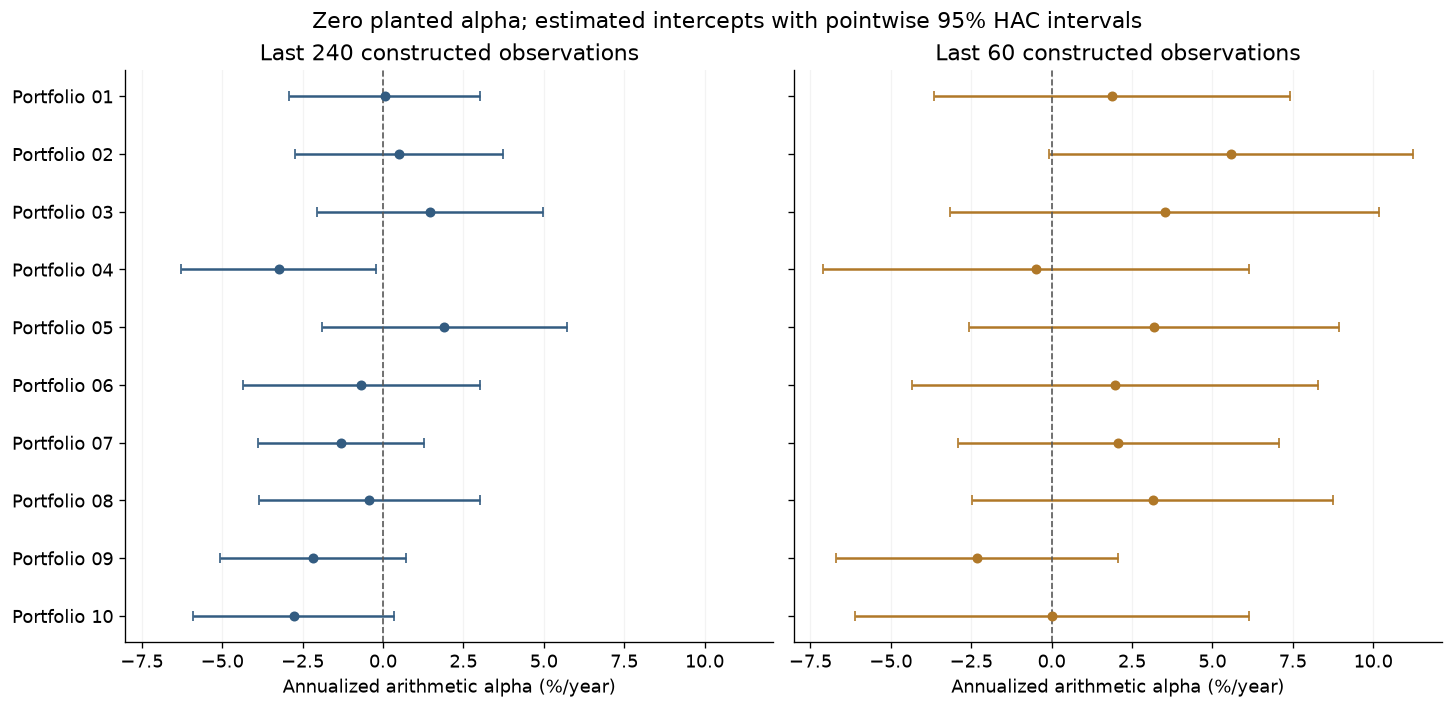

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), sharex=True, sharey=True, layout="constrained")
positions = np.arange(portfolios)
for ax, sample_size, color in zip(axes, [240, 60], ["#335C81", "#B07828"]):
    table = results[sample_size]
    width = table["Upper 95% (%/year)"] - table["Alpha (%/year)"]
    ax.errorbar(table["Alpha (%/year)"], positions, xerr=width, fmt="o", color=color,
                capsize=3, markersize=5)
    ax.axvline(0, color="0.35", linestyle="--", linewidth=1)
    ax.set(yticks=positions, yticklabels=names, title=f"Last {sample_size} constructed observations",
           xlabel="Annualized arithmetic alpha (%/year)")
    ax.grid(axis="x", alpha=0.15)
axes[0].invert_yaxis()
fig.suptitle("Zero planted alpha; estimated intercepts with pointwise 95% HAC intervals")
fig.savefig(FIGURES / "topic_alpha_uncertainty.png", dpi=160, bbox_inches="tight")
plt.show()

### 3. Do not search ten intercepts and report one as a single test

Holm's adjustment is a step-down familywise procedure and does not
require independent tests when the underlying p-values are valid.
Here the raw HAC p-values themselves rely on an asymptotic approximation;
the adjustment does not repair poor small-sample inference. The counts
below describe this one fixed realization, not a simulated rejection rate.

In [5]:
summaries = []
for sample_size, table in results.items():
    summaries.append({
        "Constructed observations": sample_size,
        "Median 95% interval width (%/year)": np.median(table["Upper 95% (%/year)"] - table["Lower 95% (%/year)"]),
        "Raw p below 0.05, out of 10": int((table["Raw p-value"] < 0.05).sum()),
        "Holm p below 0.05, out of 10": int((table["Holm p-value, family of 10"] < 0.05).sum()),
    })
summary = pd.DataFrame(summaries).set_index("Constructed observations")
display(summary.round(4))
display(results[60].round(4))

,Median 95% interval width (%/year),"Raw p below 0.05, out of 10","Holm p below 0.05, out of 10"
Constructed observations,,,
240,6.3503,1,0
60,11.4005,0,0


,Alpha (%/year),Lower 95% (%/year),Upper 95% (%/year),Raw p-value,"Holm p-value, family of 10"
Portfolio 01,1.8786,-3.6553,7.4125,0.5058,1.0000
Portfolio 02,5.5738,-0.0759,11.2235,0.0532,0.5315
Portfolio 03,3.5172,-3.1581,10.1926,0.3017,1.0000
Portfolio 04,-0.4851,-7.1058,6.1356,0.8858,1.0000
Portfolio 05,3.1947,-2.5561,8.9454,0.2762,1.0000
Portfolio 06,1.9760,-4.3299,8.2818,0.5391,1.0000
Portfolio 07,2.0787,-2.8993,7.0567,0.4131,1.0000
Portfolio 08,3.1440,-2.4696,8.7575,0.2723,1.0000
Portfolio 09,-2.3161,-6.6914,2.0591,0.2995,1.0000
Portfolio 10,0.0191,-6.1145,6.1527,0.9951,1.0000


### 4. Reconcile the intercept and the adjustment

A separate least-squares call checks the point estimates. Sorting and
cumulatively maximizing the scaled p-values independently reconstructs
the Holm step-down adjustment. These are numerical identities, not
validation of nominal confidence-interval coverage under every process.

In [6]:
direct = np.linalg.lstsq(np.column_stack([np.ones(n), X]), Y[:, 0], rcond=None)[0]
np.testing.assert_allclose(fits[240][0].coefficients, direct, atol=1e-10)
for sample_size, table in results.items():
    p_values = table["Raw p-value"].to_numpy()
    order = np.argsort(p_values)
    independent = np.empty(portfolios)
    independent[order] = np.minimum(1, np.maximum.accumulate(
        (portfolios - np.arange(portfolios)) * p_values[order]
    ))
    np.testing.assert_allclose(table["Holm p-value, family of 10"], independent, atol=1e-14)
    assert np.all(independent >= p_values - 1e-14)
full_width = summary.loc[240, "Median 95% interval width (%/year)"]
short_width = summary.loc[60, "Median 95% interval width (%/year)"]
display(Markdown(
    f"**Result for this constructed realization:** median interval width is "
    f"**{full_width:.2f} percentage points/year** with 240 observations and "
    f"**{short_width:.2f}** with 60. All ten population intercepts were set "
    "to zero, even though fitted intercepts differ. This example does not "
    "estimate a false-positive rate or prove that the HAC intervals have "
    "their nominal coverage."
))

**Result for this constructed realization:** median interval width is **6.35 percentage points/year** with 240 observations and **11.40** with 60. All ten population intercepts were set to zero, even though fitted intercepts differ. This example does not estimate a false-positive rate or prove that the HAC intervals have their nominal coverage.

## Takeaway

Interpret an ETF intercept together with its benchmark model, time
sample, uncertainty, and the family of questions examined. An omitted
exposure, changing mandate, or estimation error can all affect a fitted
intercept. A model-relative unexplained mean is not demonstrated skill
or an executable hedged return.

Read the [empirical protocol](../../research/PROTOCOL.md) and
[method references](../../research/SOURCES.md), then return to the
[combined study](../../study.ipynb).